In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyBigWig
import pyranges as pr
import scprinter as scp
import seaborn as sns
import torch
from disp_model import dispModel
from scprinter.seq.minimum_footprint import multiscaleFoot_new
from scprinter.utils import loadDispModel

In [2]:
region = "chr5:47,339,518-47,340,801"
chrom, coord = region.replace(",", "").split(":")
start, end = map(int, coord.split("-"))

# with pyBigWig.open(
#     "/mnt/filestore/scprinter/mm10Tn5Bias.tar.gz.untar/mm10Tn5Bias.bw"
# ) as bw:
#     bias = bw.values(chrom, start, end, numpy=True)
#     bias = torch.from_numpy(np.nan_to_num(bias))

# with pyBigWig.open("../03.call_peak/HPF/HPF.bw") as bw:
#     atac = bw.values(chrom, start, end, numpy=True)
#     atac = torch.from_numpy(np.nan_to_num(atac))
# np.savez('bias_and_atac.npz', bias=bias.numpy(), atac=atac.numpy())

_d = np.load("bias_and_atac.npz")
bias = torch.from_numpy(_d["bias"])
atac = torch.from_numpy(_d["atac"])

In [3]:
# all TF
new_model = "footprint_to_TFBS_conv_model.pt"
old_model = "/mnt/filestore/scprinter/TFBS_model_py.pt"

# class1 TF
# new_model = "footprint_to_TFBS_class1_conv_model.pt"
# old_model = "/mnt/filestore/scprinter/TFBS_model_class1_py.pt"

# nucleosome
# new_model = "footprint_to_nucleosome_conv_model.pt"
# old_model = "/mnt/filestore/scprinter/nucleosome_model_py.pt"

## New Footprint

In [4]:
model_path = scp.datasets.pretrained_dispersion_model
disp_model = loadDispModel(model_path)
# this dispModel is modified as you said
from copy import deepcopy

dispmodel = dispModel(deepcopy(disp_model)).to("cpu")

In [5]:
footprint = multiscaleFoot_new(
    atac[None], bias[None], torch.as_tensor([10, 20, 30, 50, 80, 100]), dispmodel
)

footprint

tensor([[[-0.2905, -0.2997, -0.3170,  ...,     nan,     nan,     nan],
         [ 1.4654,  0.8395,  1.4700,  ...,     nan,     nan,     nan],
         [ 1.4594,  1.4554,  1.2320,  ..., -0.1280, -0.1213, -0.1168],
         [    nan,     nan,     nan,  ...,  0.2853,  0.2919,  0.2965],
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan]]])

## New FP New Model

### Load new binding model

In [6]:
model = torch.jit.load(new_model)
binding_model = model.to("cpu")

### New FP post-processing and apply new model

In [7]:
final = []
from scprinter.getFootprint import *

radius = [10, 20, 30, 50, 80, 100]
for i in range(6):
    footprintPvalMatrix = footprint[:, i]
    footprintPvalMatrix = scipy.stats.norm.cdf(footprintPvalMatrix, 0, 1)
    footprintRadius = radius[i]
    smoothRadius = int(footprintRadius / 2)
    footprintPvalMatrix[np.isnan(footprintPvalMatrix)] = (
        1  # Set NA values to be pvalue = 1
    )
    # print (footprintPvalMatrix, np.sum(np.isnan(footprintPvalMatrix)), np.sum(np.isinf(footprintPvalMatrix)))
    pvalScoreMatrix = -np.log10(footprintPvalMatrix)
    pvalScoreMatrix[np.isnan(pvalScoreMatrix)] = 0
    pvalScoreMatrix[np.isinf(pvalScoreMatrix)] = 20
    if smoothRadius > 0:
        maximum_filter_size = [0] * len(pvalScoreMatrix.shape)
        maximum_filter_size[-1] = 2 * smoothRadius
        pvalScoreMatrix = maximum_filter(
            pvalScoreMatrix, tuple(maximum_filter_size), origin=-1
        )
        # Changed to smoothRadius.
        pvalScoreMatrix = rz_conv(pvalScoreMatrix, smoothRadius) / (2 * smoothRadius)
    pvalScoreMatrix[np.isnan(pvalScoreMatrix)] = 0
    pvalScoreMatrix[np.isinf(pvalScoreMatrix)] = 20
    final.append(pvalScoreMatrix)

final = np.stack(final, axis=1)
final.shape

with torch.inference_mode():
    pred2 = binding_model(torch.from_numpy(final))
new_fp_new_model = np.array(pred2.squeeze())
new_fp = final.copy()

In [8]:
new_fp.shape, new_fp_new_model.shape

((1, 6, 1283), (1083,))

## Old FP Old Model

In [9]:
import time

from scprinter.getTFBS import strided_lastaxis

In [10]:
BindingScoreModel = loadBindingScoreModel_pt(old_model)
BindingScoreModel["model"] = BindingScoreModel["model"].eval()
region_bed = pr.PyRanges(
    pd.DataFrame([pd.Series({"Chromosome": chrom, "Start": start, "End": end})])
)

In [11]:
region_identifier = None
regionATAC = atac[None, ...]
Tn5Bias = bias
region = region_bed
dispModels = disp_model
BindingScoreModel = BindingScoreModel
sites = None
tileSize = 1
contextRadius = 100
strand = "*"

if sites is not None:
    # Only keep motif matches within the region
    # Although we specified that the input sites should already be matches in the current region
    # this step prevents erros in case the user for got to take the overlap
    # sites.intersect(region)
    # sites = sites.df
    sites = sites

else:
    sites = region.window(tileSize)
    sites = sites.df
    # to make pyranges consistent with GRanges
    # Requires double check.
    # sites['End'] -= 1
    sites["End"].iloc[-1] += 1
    sites["Score"] = 1
    sites["TF"] = ""
    ## Yan, could you confirm if it's OK to do this?
    skip_site_check = False
if "Strand" not in sites:
    sites["Strand"] = "*"
    skip_site_check = True
else:
    skip_site_check = False
if strand != "*":
    skip_site_check = True

width = len(Tn5Bias)
scales = BindingScoreModel["scales"]
multiScaleFootprints = None

start = time.time()
for scale_index, scale in enumerate(scales):
    # I changed the code in regionFootprintscore to make it consistent
    footprintScores, _ = regionFootprintScore(
        regionATAC, Tn5Bias, dispModels[str(scale)], scale, scale, None
    )
    if multiScaleFootprints is None:
        # shape of (group, scale, position)
        multiScaleFootprints = np.zeros(
            (footprintScores.shape[0], len(scales), footprintScores.shape[1]),
            dtype="float32",
        )
    multiScaleFootprints[:, scale_index, :] = footprintScores
footprint_time = time.time() - start

old_fp = multiScaleFootprints.copy()

# Calculate positions of TF sites relative to the start of the CRE region
relativePos = (
    np.array(sites["Start"] + sites["End"]) * 0.5 - int(region.df["Start"].iloc[0])
).astype("int")
# Only keep sites with distance to CRE edge >= contextRadius
siteFilter = (relativePos > contextRadius) & (relativePos <= (width - contextRadius))
if np.sum(siteFilter) == 0:
    print(sites, region, relativePos, contextRadius, width - contextRadius)
    print("no sites in the region")
sites = sites.iloc[siteFilter]
relativePos = relativePos[siteFilter]

# Go through each site and calculate predicted TF binding score for each pseudobulk
score = np.array(sites["Score"])
score = score[None, :, None]
start = time.time()

if len(sites) > 0:
    start_site = relativePos - contextRadius - 1
    slice_width = 2 * contextRadius + 1
    # This is the stride trick
    # shape of, (group, scale, sites, 2 * contextRadius + 1)
    siteFootprints = strided_lastaxis(multiScaleFootprints, slice_width)[
        :, :, start_site
    ]

    if not skip_site_check:
        mask = np.isin(sites["Strand"], ["-", "-1", -1])
        # print ("neg strand", np.sum(mask))
        siteFootprints[:, :, mask] = siteFootprints[:, :, mask][..., ::-1]
    if strand == "-":
        siteFootprints = siteFootprints[..., ::-1]

    stride_time = time.time() - start
    start = time.time()

    # shape of (group, sites, scale, 2 * context Radius + 1)
    # then reshaped to (group, sites, scale * (2 * context Radius + 1))
    BindingScoreData = np.transpose(siteFootprints, axes=[0, 2, 1, 3]).reshape(
        (siteFootprints.shape[0], siteFootprints.shape[2], -1)
    )
    # BindingScoreData = np.concatenate([BindingScoreData,
    #                                    score], axis=-1)

    transpose_time = time.time() - start
    start = time.time()

    # score = torch_predict_BindingScore(BindingScoreData, BindingScoreModel)
    if "model" in BindingScoreModel:
        with torch.inference_mode():
            score = BindingScoreModel["model"](
                torch.from_numpy(BindingScoreData).float()
            ).numpy()
    else:
        raise

else:
    BindingScoreData = None

In [12]:
old_fp_old_model = score.ravel().copy()

## New FP Old Model

In [13]:
region_identifier = None
regionATAC = atac[None, ...]
Tn5Bias = bias
region = region_bed
dispModels = disp_model
BindingScoreModel = BindingScoreModel
sites = None
tileSize = 1
contextRadius = 100
strand = "*"

if sites is not None:
    # Only keep motif matches within the region
    # Although we specified that the input sites should already be matches in the current region
    # this step prevents erros in case the user for got to take the overlap
    # sites.intersect(region)
    # sites = sites.df
    sites = sites

else:
    sites = region.window(tileSize)
    sites = sites.df
    # to make pyranges consistent with GRanges
    # Requires double check.
    # sites['End'] -= 1
    sites["End"].iloc[-1] += 1
    sites["Score"] = 1
    sites["TF"] = ""
    ## Yan, could you confirm if it's OK to do this?
    skip_site_check = False
if "Strand" not in sites:
    sites["Strand"] = "*"
    skip_site_check = True
else:
    skip_site_check = False
if strand != "*":
    skip_site_check = True

width = len(Tn5Bias)
scales = BindingScoreModel["scales"]
multiScaleFootprints = None

start = time.time()
for scale_index, scale in enumerate(scales):
    # I changed the code in regionFootprintscore to make it consistent
    footprintScores, _ = regionFootprintScore(
        regionATAC, Tn5Bias, dispModels[str(scale)], scale, scale, None
    )
    if multiScaleFootprints is None:
        # shape of (group, scale, position)
        multiScaleFootprints = np.zeros(
            (footprintScores.shape[0], len(scales), footprintScores.shape[1]),
            dtype="float32",
        )
    multiScaleFootprints[:, scale_index, :] = footprintScores
footprint_time = time.time() - start

old_fp = multiScaleFootprints.copy()


# Calculate positions of TF sites relative to the start of the CRE region
relativePos = (
    np.array(sites["Start"] + sites["End"]) * 0.5 - int(region.df["Start"].iloc[0])
).astype("int")
# Only keep sites with distance to CRE edge >= contextRadius
siteFilter = (relativePos > contextRadius) & (relativePos <= (width - contextRadius))
if np.sum(siteFilter) == 0:
    print(sites, region, relativePos, contextRadius, width - contextRadius)
    print("no sites in the region")
sites = sites.iloc[siteFilter]
relativePos = relativePos[siteFilter]

# Go through each site and calculate predicted TF binding score for each pseudobulk
score = np.array(sites["Score"])
score = score[None, :, None]
start = time.time()

if len(sites) > 0:
    start_site = relativePos - contextRadius - 1
    slice_width = 2 * contextRadius + 1
    # This is the stride trick
    # shape of, (group, scale, sites, 2 * contextRadius + 1)
    siteFootprints = strided_lastaxis(new_fp, slice_width)[:, :, start_site]

    if not skip_site_check:
        mask = np.isin(sites["Strand"], ["-", "-1", -1])
        # print ("neg strand", np.sum(mask))
        siteFootprints[:, :, mask] = siteFootprints[:, :, mask][..., ::-1]
    if strand == "-":
        siteFootprints = siteFootprints[..., ::-1]

    stride_time = time.time() - start
    start = time.time()

    # shape of (group, sites, scale, 2 * context Radius + 1)
    # then reshaped to (group, sites, scale * (2 * context Radius + 1))
    BindingScoreData = np.transpose(siteFootprints, axes=[0, 2, 1, 3]).reshape(
        (siteFootprints.shape[0], siteFootprints.shape[2], -1)
    )
    # BindingScoreData = np.concatenate([BindingScoreData,
    #                                    score], axis=-1)

    transpose_time = time.time() - start
    start = time.time()

    # score = torch_predict_BindingScore(BindingScoreData, BindingScoreModel)
    if "model" in BindingScoreModel:
        with torch.inference_mode():
            score = BindingScoreModel["model"](
                torch.from_numpy(BindingScoreData).float()
            ).numpy()
    else:
        raise

else:
    BindingScoreData = None

In [14]:
new_fp_old_model = score.ravel().copy()

## Old FP New Model

In [15]:
with torch.inference_mode():
    pred2 = binding_model(torch.from_numpy(old_fp[None]))
old_fp_new_model = np.array(pred2.squeeze())

Text(0.5, 1.0, 'Old FP New TFBS Model')

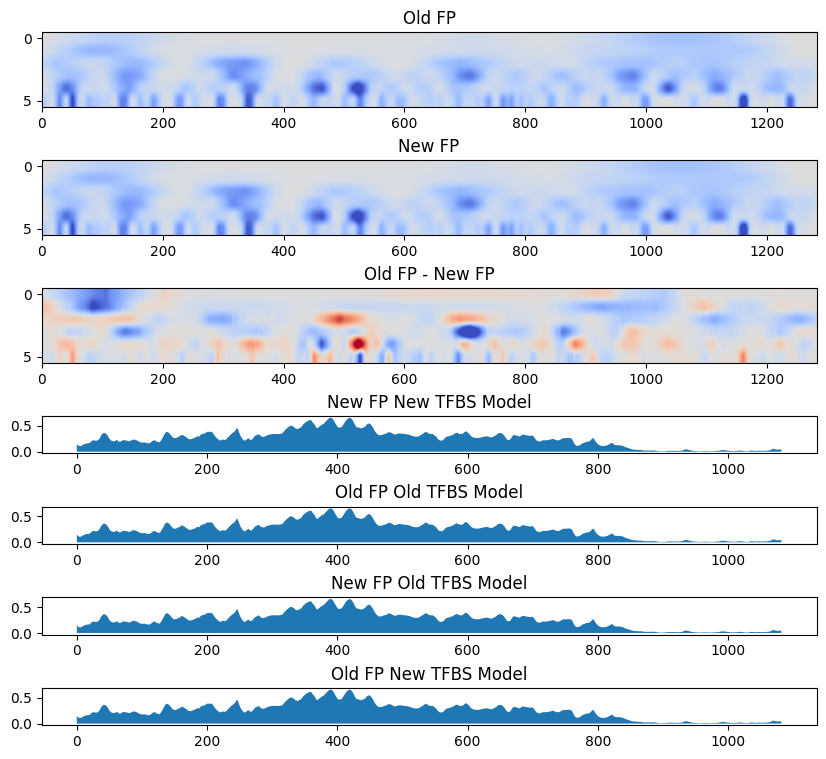

In [16]:
fig = plt.figure(figsize=(10, 9))
height_ratios = (2, 2, 2, 1, 1, 1, 1)
gs = fig.add_gridspec(nrows=len(height_ratios), height_ratios=height_ratios, hspace=1)
axes = [fig.add_subplot(gs[i]) for i in range(len(height_ratios))]

ax = axes[0]
old = old_fp.squeeze()[::-1]
ax.imshow(old, aspect="auto", vmin=-2, vmax=2, cmap="coolwarm_r")
ax.set_title("Old FP")
ax = axes[1]
new = new_fp.squeeze()[::-1]
ax.imshow(new, aspect="auto", vmin=-2, vmax=2, cmap="coolwarm_r")
ax.set_title("New FP")
ax = axes[2]
e = 1e-6
ax.imshow(old - new, aspect="auto", vmin=-e, vmax=e, cmap="coolwarm_r")
ax.set_title("Old FP - New FP")
ax = axes[3]
ax.fill_between(range(np.array(new_fp_new_model).size), new_fp_new_model.squeeze())
ax.set_title("New FP New TFBS Model")
ax = axes[4]
ax.fill_between(range(old_fp_old_model.size), old_fp_old_model)
ax.set_title("Old FP Old TFBS Model")
ax = axes[5]
ax.fill_between(range(np.array(new_fp_old_model).size), new_fp_old_model.squeeze())
ax.set_title("New FP Old TFBS Model")
ax = axes[6]
ax.fill_between(range(old_fp_new_model.size), old_fp_new_model)
ax.set_title("Old FP New TFBS Model")